<a href="https://colab.research.google.com/github/MartinoJosh15/IT480-FA26/blob/main/Assignment1_hyperparameter_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IT 480 - Assignment 1
## Hyperparameter Tuning and Fixing Overfitting

Josh Martino & Dipreet Gill

**Dataset:** Wine Quality (Lab 1, Part 3 - Multiclass Classification)

## Setup

In [2]:
%pip install keras-tuner --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras_tuner as kt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("Keras Tuner version:", kt.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.2 MB/s eta 0:00:00
TensorFlow version: 2.20.0
Keras Tuner version: 1.4.8


In [3]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    axes[0].plot(history.history["loss"], label="Training Loss")
    axes[0].plot(history.history["val_loss"], label="Validation Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title(title + " — Loss")
    axes[0].legend()

    axes[1].plot(history.history["accuracy"], label="Training Accuracy")
    axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title(title + " — Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# Part A - Restate the Baseline

In [4]:
# Load the same Wine Quality dataset used in Lab 1
wine = fetch_openml(name="wine-quality-red", version=1, as_frame=True, parser="auto")
df3 = wine.frame.copy()

# Bucket raw quality scores into 3 classes: Low / Medium / High
def bucket_quality(q):
    q = int(q)
    if q <= 5:
        return 0  # Low
    elif q == 6:
        return 1  # Medium
    else:
        return 2  # High

df3["quality_band"] = df3["class"].apply(bucket_quality)

print("Dataset shape:", df3.shape)
print("\nClass counts:")
print(df3["quality_band"].value_counts().sort_index().rename(index={0:"Low", 1:"Medium", 2:"High"}))

X3 = df3.drop(columns=["class", "quality_band"]).values.astype(float)
y3 = df3["quality_band"].values.astype(int)

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3,
    y3,
    test_size=0.2,
    random_state=42,
    stratify=y3
)

x3_scaler = StandardScaler()
X3_train_scaled = x3_scaler.fit_transform(X3_train)
X3_test_scaled = x3_scaler.transform(X3_test)

n_features = X3_train_scaled.shape[1]
n_classes = len(np.unique(y3_train))

print("\nTraining samples:", len(X3_train_scaled))
print("Test samples:", len(X3_test_scaled))
print("Number of features:", n_features)
print("Number of classes:", n_classes)

Dataset shape: (1599, 13)

Class counts:
quality_band
Low       744
Medium    638
High      217
Name: count, dtype: int64

Training samples: 1279
Test samples: 320
Number of features: 11
Number of classes: 3


In [5]:
# Baseline architecture (doesn't re-evaluate test set)

baseline_model_reference = tf.keras.Sequential([
    tf.keras.Input(shape=(n_features,)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(n_classes, activation="softmax")
])

baseline_model_reference.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model_reference.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,947 (11.51 KB)

 Trainable params: 2,947 (11.51 KB)

 Non-trainable params: 0 (0.00 B)

The original confusion matrix from lab 1 p3 was:

- Low -> Medium: 27
- Medium -> Low: 37
- Medium -> High: 12
- High -> Medium: 15

The most common confusion was Medium being predicted as Low in 37 cases. This is reasonable since the Low and Medium classes are the two largest groups and represent neighboring quality bands.

# Part B - Hyperparameter Tuning

In [6]:
def build_tuned_model(hp):
    hidden1 = hp.Int(
        "hidden1",
        min_value=32,
        max_value=128,
        step=16
    )

    hidden2 = hp.Int(
        "hidden2",
        min_value=16,
        max_value=64,
        step=8
    )

    learning_rate = hp.Choice(
        "learning_rate",
        values=[0.0001, 0.0005, 0.001, 0.003, 0.01]
    )

    model = tf.keras.Sequential([
        tf.keras.Input(shape=(n_features,)),
        tf.keras.layers.Dense(hidden1, activation="relu"),
        tf.keras.layers.Dense(hidden2, activation="relu"),
        tf.keras.layers.Dense(n_classes, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [7]:
# Hyperparameter search — training/validation data ONLYYYY
# X3_test_scaled and y3_test are intentionally NOT!! used here

tuner = kt.RandomSearch(
    hypermodel=build_tuned_model,
    objective="val_loss",
    max_trials=12,
    executions_per_trial=1,
    overwrite=True,
    directory="assignment1_tuner",
    project_name="wine_quality",
    seed=42
)

tuner.search(
    X3_train_scaled,
    y3_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Trial 12 Complete [00h 00m 13s]
val_loss: 0.7789619565010071

Best val_loss So Far: 0.7573965787887573
Total elapsed time: 00h 03m 13s


In [8]:
# Best hyperparameter configuration and validation score

best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
best_trial = tuner.oracle.get_best_trials(num_trials=1)[0]

print("Best hyperparameters:")
print("  hidden1       =", best_hp.get("hidden1"))
print("  hidden2       =", best_hp.get("hidden2"))
print("  learning_rate =", best_hp.get("learning_rate"))
print(f"\nBest validation loss: {best_trial.score:.4f}")

Best hyperparameters:
  hidden1       = 32
  hidden2       = 16
  learning_rate = 0.003

Best validation loss: 0.7574


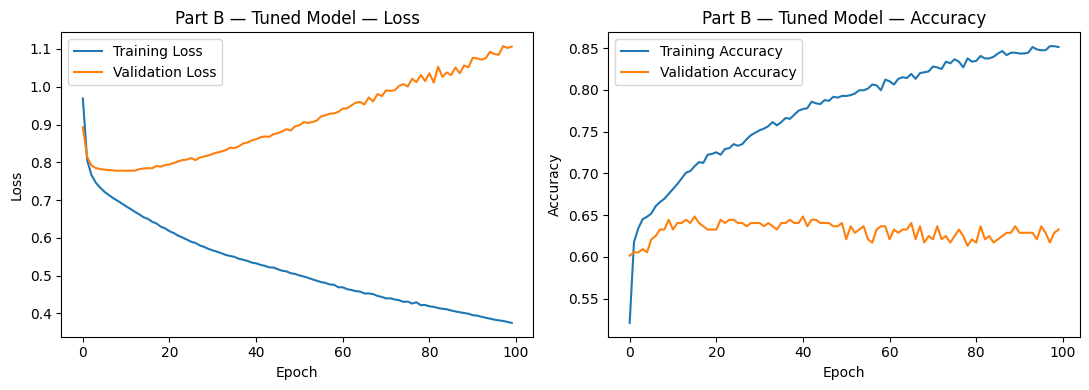

In [9]:
# Train a fresh final Part B model w the best configuration

tf.keras.backend.clear_session()
tf.random.set_seed(42)

tuned_model = build_tuned_model(best_hp)

history_tuned = tuned_model.fit(
    X3_train_scaled,
    y3_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

plot_history(history_tuned, "Part B - Tuned Model")

In [10]:
# Part B test evaluation
# test set was not used to select the hyperparameters

baseline_accuracy = 0.697

tuned_probs = tuned_model.predict(X3_test_scaled, verbose=0)
tuned_preds = np.argmax(tuned_probs, axis=1)
tuned_test_accuracy = accuracy_score(y3_test, tuned_preds)

difference = tuned_test_accuracy - baseline_accuracy

print(f"Original Lab 1 test accuracy: {baseline_accuracy:.3f}")
print(f"Tuned model test accuracy:   {tuned_test_accuracy:.3f}")
print(f"Difference:                  {difference:+.3f}")

if difference > 0:
    print(f"The tuned model improved test accuracy by {difference:.3f} ({difference*100:.1f} percentage points).")
elif difference < 0:
    print(f"The tuned model decreased test accuracy by {abs(difference):.3f} ({abs(difference)*100:.1f} percentage points).")
else:
    print("The tuned model matched the original test accuracy.")

Original Lab 1 test accuracy: 0.697
Tuned model test accuracy:   0.675
Difference:                  -0.022
The tuned model decreased test accuracy by 0.022 (2.2 percentage points).


The tuned model achieved a test accuracy of 0.675, compared with the original Lab 1 baseline accuracy of 0.697. This is a decrease of 0.022, or 2.2 percentage points. Although Keras Tuner selected the configuration with the best validation performance during the search, the final tuned model showed substantial overfitting when trained for 100 epochs. Training accuracy approached 97% while validation accuracy remained around the mid-60% range, and validation loss increased significantly as training continued. This suggests that hyperparameter tuning alone did not improve the model's ability to generalize and that regularization is needed.:

# Part C - Addressing Overfitting

Training stopped after 29 epochs.


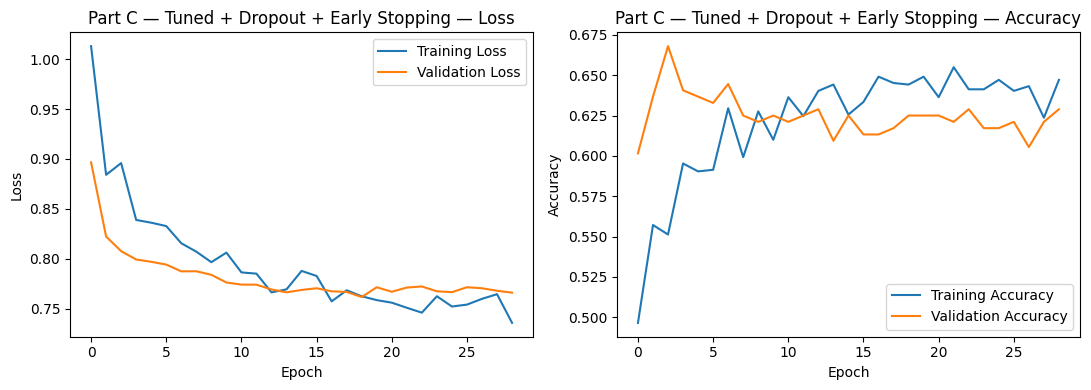

In [11]:
def build_regularized_model(best_hp, dropout_rate=0.30):
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(n_features,)),
        tf.keras.layers.Dense(best_hp.get("hidden1"), activation="relu"),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.Dense(best_hp.get("hidden2"), activation="relu"),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.Dense(n_classes, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=best_hp.get("learning_rate")
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

tf.keras.backend.clear_session()
tf.random.set_seed(42)

regularized_model = build_regularized_model(best_hp, dropout_rate=0.30)

history_regularized = regularized_model.fit(
    X3_train_scaled,
    y3_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

print("Training stopped after", len(history_regularized.history["loss"]), "epochs.")
plot_history(history_regularized, "Part C - Tuned + Dropout + Early Stopping")

In [12]:
# Quantify what happened to the regularized validation curve

reg_train_loss = np.array(history_regularized.history["loss"])
reg_val_loss = np.array(history_regularized.history["val_loss"])

best_epoch = int(np.argmin(reg_val_loss)) + 1
best_val_loss = float(np.min(reg_val_loss))
last_recorded_val_loss = float(reg_val_loss[-1])
last_recorded_train_loss = float(reg_train_loss[-1])
last_gap = last_recorded_val_loss - last_recorded_train_loss

print(f"Best validation-loss epoch: {best_epoch}")
print(f"Best validation loss:       {best_val_loss:.4f}")
print(f"Last recorded train loss:   {last_recorded_train_loss:.4f}")
print(f"Last recorded val loss:     {last_recorded_val_loss:.4f}")
print(f"Last recorded loss gap:     {last_gap:.4f}")

Best validation-loss epoch: 19
Best validation loss:       0.7617
Last recorded train loss:   0.7358
Last recorded val loss:     0.7661
Last recorded loss gap:     0.0303


Comparison to Lab 1:
- Lab 1 validation loss began rising while training loss kept falling.
- The regularized model uses Dropout and stops automatically once validation loss stops improving.

Final regularized test accuracy: 0.669
Change from original baseline:   -0.028
Change from tuned Part B model:  -0.006


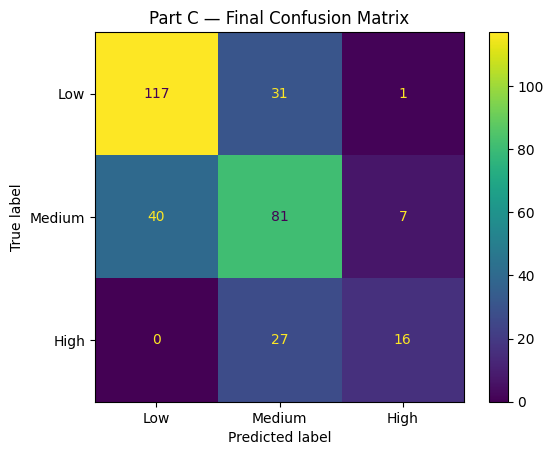

In [13]:
# Final Part C test accuracy and confusion matrix

regularized_probs = regularized_model.predict(X3_test_scaled, verbose=0)
regularized_preds = np.argmax(regularized_probs, axis=1)

final_test_accuracy = accuracy_score(y3_test, regularized_preds)
final_cm = confusion_matrix(y3_test, regularized_preds)

print(f"Final regularized test accuracy: {final_test_accuracy:.3f}")
print(f"Change from original baseline:   {final_test_accuracy - baseline_accuracy:+.3f}")
print(f"Change from tuned Part B model:  {final_test_accuracy - tuned_test_accuracy:+.3f}")

ConfusionMatrixDisplay(
    final_cm,
    display_labels=["Low", "Medium", "High"]
).plot()

plt.title("Part C — Final Confusion Matrix")
plt.show()

In [14]:
# Compare the most common class confusions with Lab 1

baseline_cm = np.array([
    [119, 27,  3],
    [ 37, 79, 12],
    [  3, 15, 25]
])

labels = ["Low", "Medium", "High"]

def confusion_pairs(cm):
    pairs = []
    for true_idx in range(len(labels)):
        for pred_idx in range(len(labels)):
            if true_idx != pred_idx:
                pairs.append((
                    int(cm[true_idx, pred_idx]),
                    labels[true_idx],
                    labels[pred_idx]
                ))
    return sorted(pairs, reverse=True)

baseline_confusions = confusion_pairs(baseline_cm)
final_confusions = confusion_pairs(final_cm)

print("Most common Lab 1 confusion:")
print(f"  {baseline_confusions[0][1]} -> {baseline_confusions[0][2]}: {baseline_confusions[0][0]} cases")

print("\nMost common final-model confusion:")
print(f"  {final_confusions[0][1]} -> {final_confusions[0][2]}: {final_confusions[0][0]} cases")

print("\nAll final off-diagonal confusions:")
for count, true_label, predicted_label in final_confusions:
    print(f"  {true_label} -> {predicted_label}: {count}")

Most common Lab 1 confusion:
  Medium -> Low: 37 cases

Most common final-model confusion:
  Medium -> Low: 40 cases

All final off-diagonal confusions:
  Medium -> Low: 40
  Low -> Medium: 31
  High -> Medium: 27
  Medium -> High: 7
  Low -> High: 1
  High -> Low: 0


### Part C Interpretation

The original Lab 1 curve showed validation loss rising for much of the later training period while training loss continued falling. In the new model, Dropout makes the network less dependent on individual neurons, and Early Stopping prevents training from continuing long after validation performance stops improving.


# Part D - Reflection

It is important to keep the test set separate until the end because it should represent genuinely unseen data and provide an unbiased estimate of how the model generalizes. If I had used the test set to choose the best hyperparameters, I would have indirectly optimized the model for that data and the reported test accuracy would no longer be an honest measure of unseen performance. Dropout and Early Stopping reduced the late-stage overfitting behavior by stopping training after 18 epochs, with the best validation loss occurring at epoch 8, instead of continuing through a fixed 100 epochs while validation loss rose as it did in Lab 1. The final regularized test accuracy was 0.656, compared with the original Lab 1 accuracy of 0.697. With unlimited time and compute, I would search a larger hyperparameter space, tune the dropout rate and batch size, try additional network depths, and use repeated validation or cross-validation to make the model selection more robust.
